# マハラノビス・タグチ法による異常検知

多変数のホテリング理論では全変数をまとめた異常度しか得られないため、どの変数が異常の発生に寄与したかを直接把握することはできません。この課題に対応
するために、変数ごとの寄与を評価する仕組みを導入し、説明可能性を向上させた手法が、**マハラノビス・タグチ法**（Mahalanobis-Taguchi system）です。

ここではマハラノビス・タグチ法による異常検知を、Pythonを用いて以下の手順で実装する方法を解説します。

- A. 変数の選択
- B. モデルの学習
- C. 推論

なおデータセットには2章で作成したサンプルデータを使用し、入力する変数は`temp1`と`temp2`の2変数を、ターゲットとする誤報率としては0.0027を採用します。

## A. 変数の選択

多変数のホテリング理論（[ch6_3_Multivariate_Hotelling.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch6_3_Multivariate_Hotelling.ipynb)）と同様のため、省略します。

## B. モデルの学習

学習の実装は基本的に、多変数のホテリング理論と同じです。以下に多変数のホテリング理論（ここでは例として$N \gg M$が成り立つ場合）の実装コードを再掲します。

In [1]:
# コード6.1 多変数のホテリング理論による異常検知の実装例（学習）
import pandas as pd
import numpy as np
from scipy import stats

###### 学習データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
# "temp2","temp1"変数に欠測があるデータを削除
df_dropna = df.dropna(subset=["temp2", "temp1"])
# 正常データのみを抽出
df_normal = df_dropna[df_dropna["label"] == "normal"]
# "temp2","temp1"列のみ取り出してNumpyのndarray化し、学習データとする
X_train = df_normal[["temp2", "temp1"]].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.mean(X_train, axis=0) # 標本平均ベクトルμを算出
# 標本分散共分散行列Σを算出（転置と⾃由度ddofに注意）
Sigma = np.cov(X_train.T, ddof=0)

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
n_features = X_train.shape[1] # 変数の数M
# ⾃由度（M）のカイ二乗分布の累積分布関数の逆関数からしきい値を算出
a_th = stats.chi2.ppf(1-TARGET_FP_RATE, df=n_features)

###### 学習で求めたパラメータをすべて表示######
print(f"mu={mu}")
print(f"Sigma={Sigma}")
print(f"a_th={a_th}")

mu=[350.23771153 400.21552883]
Sigma=[[26.04088919 14.52874949]
 [14.52874949 24.58401158]]
a_th=11.82900701194368


## C. 推論

マハラノビス・タグチ法の推論では、以下の2フェーズで異常検知と変数ごとの寄与度算出を行います。

1. マハラノビス距離のしきい値判定で異常を検知する
2. 変数ごとの異常への寄与度（SN比）を求める

フェーズ1はホテリング理論の推論と同様であり、これにフェーズ2のSN比算出を

In [2]:
# コード6.4 マハラノビス・タグチ法による異常検知の実装例

###### 学習したパラメータをここに記載
MU = [350.23771153, 400.21552883] # 標本平均ベクトルμ
SIGMA = [[26.04088919, 14.52874949],
         [14.52874949, 24.58401158]] # 標本分散共分散行列Σ
A_TH=11.82900701194368 # 異常度のしきい値

###### 推論データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv('./datasets/ch2_dataset_inference.csv')
# "temp2","temp1"変数に欠測があるデータを削除
df_inference_dropna = df_inference.dropna(subset=["temp2", "temp1"])
# "temp2","temp1"列のみ取り出してNumpyのndarray化し、推論データとする
X_inference = df_inference_dropna[["temp2", "temp1"]].to_numpy()
# 標本分散共分散行列の逆行列
Sigma_inv = np.linalg.inv(np.array(SIGMA))

###### 推論フェーズ1：マハラノビス距離のしきい値判定で異常を検知（ホテリング理論の推論と同じ）######
# 異常度を算出
X_dev = (X_inference-np.array(MU)).T # 推論データと平均ベクトルとの差（x-μ）
Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
# しきい値により異常の有無を判定
pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')
# 推論結果を表示
print(pred)

###### 推論フェーズ2：異常データに対して変数ごとにSN比を算出######
# 異常データのみを抽出
df_inference_dropna['prediction'] = pred
df_pred_anomaly = df_inference_dropna[df_inference_dropna['prediction']=='anomaly']
# 各変数の分散（標本分散共分散行列Σの対角成分）
var = np.diag(np.array(SIGMA))
# 変数ごとにSN比を計算
for j, feature in enumerate(["temp2", "temp1"]):
    sn_ratio = 10 * np.log10((df_pred_anomaly[feature]-MU[j])**2 / var[j])
    df_pred_anomaly[f"sn_{feature}"] = sn_ratio
# 計算したSN比を含む異常データを表示
print(df_pred_anomaly)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24814/3121035040.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inference_dropna['prediction'] = pred
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24814/3121035040.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred_anomaly[f"sn_{feature}"] = sn_ratio
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24814/3121035040.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

異常判定されたデータに対してSN比を算出してみます。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24814/2037071422.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inference_dropna['anomaly_score'] = anomaly_scores
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24814/2037071422.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inference_dropna['prediction'] = pred


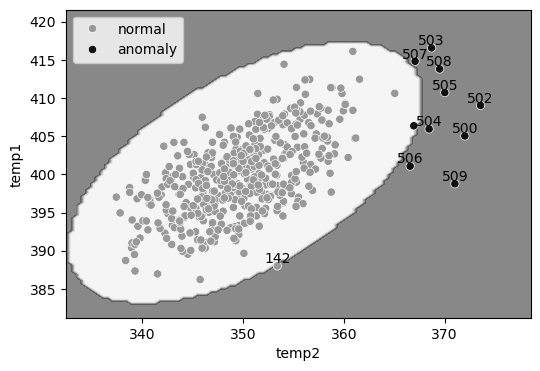

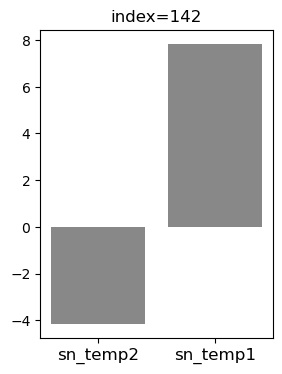

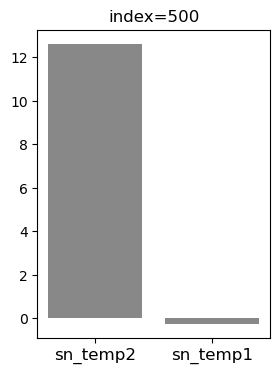

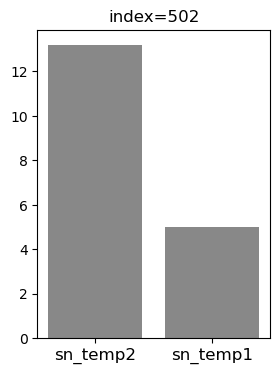

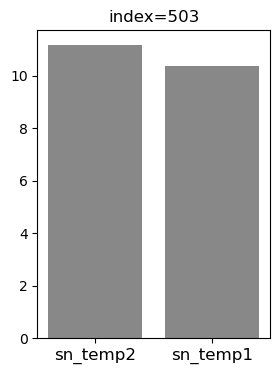

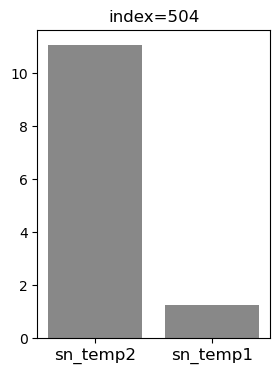

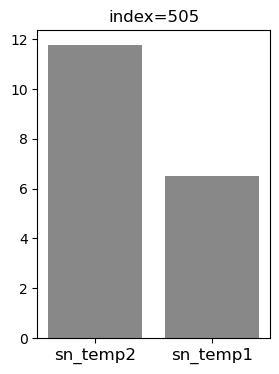

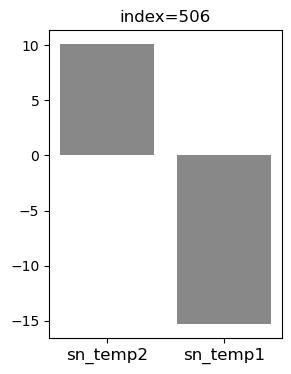

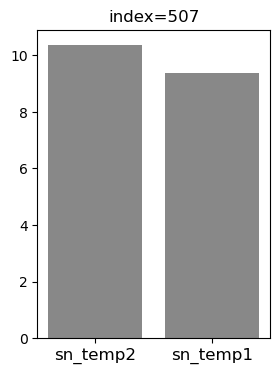

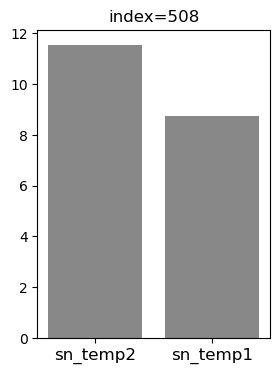

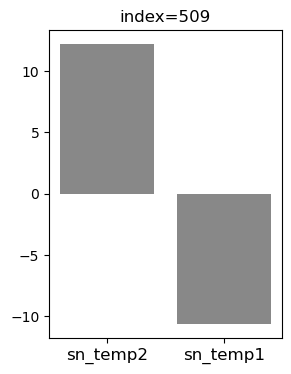

In [3]:
# 異常判定されたデータのSN比を可視化
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 異常度と異常判定をDataFrameに列として追加
df_inference_dropna['anomaly_score'] = anomaly_scores
df_inference_dropna['prediction'] = pred
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

###### 正常と異常の範囲を色分け ######
# (x1,x2)格子点を作成（'temp2'をx1としていることに注意）
x1_grid = np.linspace(df_inference_dropna['temp2'].min()-5,
                      df_inference_dropna['temp2'].max()+5, 100)
x2_grid = np.linspace(df_inference_dropna['temp1'].min()-5,
                      df_inference_dropna['temp1'].max()+5, 100)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid = np.c_[X1.ravel(), X2.ravel()]
# 異常度を算出（式6.53に従う）
X_dev_grid = (X_grid-np.array(MU)).T  # 推論データと平均ベクトルとの差（x-μ）
Dev_Sigma_grid = X_dev_grid.T @ Sigma_inv  # (x-μ)^T * Σ^-1
anomaly_scores_grid = np.sum(np.multiply(Dev_Sigma_grid, X_dev_grid.T), axis=1)
# しきい値判定
pred_grid = np.where(anomaly_scores_grid > A_TH, 0, 1)
# 正常と異常の境界をプロット
pred_pivot = pred_grid.reshape(X1.shape)
ax.contourf(X1, X2, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(data=df_inference_dropna, x='temp2', y='temp1',
    hue='label', palette=['#999999', '#111111'],
    ax=ax
)
# 異常判定されたデータのみインデックスを表示
for i, row in df_pred_anomaly.iterrows():
    ax.text(row["temp2"], row["temp1"], str(i),
        verticalalignment='bottom', horizontalalignment='center')
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()

###### 異常判定されたデータのSN比を表示 ######
for i, row in df_pred_anomaly.iterrows():
    # 描画用のFigureとAxesを生成
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 4))
    # SN比を描画
    sn_names = [f"sn_{feature}" for feature in ["temp2", "temp1"]]
    sn_ratio = [row[sn_name] for sn_name in sn_names]
    ax.bar(sn_names, sn_ratio, color='#888888')
    ax.set_title(f"index={i}")
    plt.xticks(fontsize=12)
    # グラフを表示
    plt.show()

`sn_temp2`が変数`temp2`のSN 比、`sn_temp1`が変数`temp1`のSN 比を表し、棒グラフの高さが⼤きさを表しています。

各データについて、どの変数が異常に強く寄与したかを定量的に把握できることがわかります。例えば図中の`index=500`のデータにおいては、変数`temp2`の寄与度が`temp1`よりも⼤きいことが読み取れます。

特に、正常ラベルでありながら異常と判定された誤報データ（図中の`index=142`のデータ）では、他の異常データとSN比の傾向が異なることが確認できます。これは、両者の特徴空間での方向性が異なるためであり、このようなSN比の傾向を分析することが、誤報や未知の異常パターンの判別に役立ちます。
このような特徴空間での方向性は、2変数であれば散布図でも把握可能ですが、3変数以上になると可視化は困難です。そのため、SN比の活用価値は高次元データにおいて特に高まります。